# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/prarthanamahesh21-hub/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [ ]:
# Week-7 setup: rebuild the validated modeling frame and fit the final
# decision-support model on the available March modeling data.

import numpy as np
import pandas as pd
import duckdb

from google.colab import userdata
from datasets import load_dataset

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Load Hugging Face token
HF_TOKEN = userdata.get("HF_TOKEN")
print("Hugging Face token loaded:", HF_TOKEN is not None)

# Load the same source tables used in Week 5
dim_content = load_dataset(
    "FlyRank/internship-warehouse",
    "dim_content",
    token=HF_TOKEN
)

fact_performance = load_dataset(
    "FlyRank/internship-warehouse",
    "fact_content_daily_performance",
    token=HF_TOKEN
)

content = dim_content["train"]
performance = fact_performance["train"]

# Register source tables in DuckDB
con = duckdb.connect()

con.register("dim_content", content._data.table)
con.register(
    "fact_content_daily_performance",
    performance._data.table
)

print("Source tables loaded and registered.")
print("Content rows:", len(content))
print("Performance rows:", len(performance))

# Same five validated features used in Week 5
final_features = [
    "content_age_days",
    "word_count",
    "gsc_impressions_90d",
    "gsc_clicks_90d",
    "ga4_pageviews_90d"
]

# Recreate the March decision frame
features_march = con.sql("""
WITH performance_90d AS (
    SELECT
        content_hash_id,

        SUM(
            CASE
                WHEN gsc_data_available IS TRUE
                THEN COALESCE(gsc_impressions, 0)
                ELSE 0
            END
        ) AS gsc_impressions_90d,

        SUM(
            CASE
                WHEN gsc_data_available IS TRUE
                THEN COALESCE(gsc_clicks, 0)
                ELSE 0
            END
        ) AS gsc_clicks_90d,

        SUM(
            CASE
                WHEN ga4_data_available IS TRUE
                THEN COALESCE(ga4_pageviews, 0)
                ELSE 0
            END
        ) AS ga4_pageviews_90d

    FROM fact_content_daily_performance

    WHERE report_date >= DATE '2025-12-01'
      AND report_date < DATE '2026-03-01'

    GROUP BY content_hash_id
)

SELECT
    c.content_hash_id,

    DATE_DIFF(
        'day',
        CAST(c.content_created_date AS DATE),
        DATE '2026-03-01'
    ) AS content_age_days,

    c.word_count,

    COALESCE(p.gsc_impressions_90d, 0) AS gsc_impressions_90d,
    COALESCE(p.gsc_clicks_90d, 0) AS gsc_clicks_90d,
    COALESCE(p.ga4_pageviews_90d, 0) AS ga4_pageviews_90d

FROM dim_content c

LEFT JOIN performance_90d p
    ON c.content_hash_id = p.content_hash_id

WHERE c.content_created_date < DATE '2026-03-01'
  AND c.is_published IS TRUE
  AND c.is_deleted IS FALSE
""").df()

print("March decision frame:", features_march.shape)
print(features_march[final_features].isna().sum())

# Recreate the future April label exactly as in Week 5
future_label = con.sql("""
SELECT
    content_hash_id,

    SUM(
        CASE
            WHEN gsc_data_available IS TRUE
            THEN COALESCE(gsc_clicks, 0)
            ELSE 0
        END
    ) AS future_gsc_clicks

FROM fact_content_daily_performance

WHERE report_date >= DATE '2026-04-01'
  AND report_date < DATE '2026-05-01'

GROUP BY content_hash_id
""").df()

future_label["label"] = (
    future_label["future_gsc_clicks"] > 0
).astype(int)

model_df = features_march.merge(
    future_label[["content_hash_id", "label"]],
    on="content_hash_id",
    how="inner"
)

print("Validated model frame:", model_df.shape)
print("Positive labels:", model_df["label"].sum())
print("Negative labels:", (model_df["label"] == 0).sum())

# Fit the same Logistic Regression approach used in Week 5.
# For the Week-7 queue, fit using all available labeled modeling rows.
final_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

final_model.fit(
    model_df[final_features],
    model_df["label"]
)

print("Final decision-support model fitted.")

Hugging Face token loaded: True


Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/39 [00:00<?, ?it/s]

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


### Ranked actions + reason codes

The ranked queue is intended to prioritize pages for **human review**, not to automatically refresh content. Pages are ranked by the validated model score, with higher scores indicating higher predicted likelihood of being a useful refresh candidate.

Reason codes make the ranking easier to interpret. They summarize observable signals associated with the page, such as older content, lower search engagement, or lower recent page activity. These codes are decision-support explanations, not causal findings.

The recommended action levels are:

* **Priority review:** review first because the model score is high and one or more supporting signals are present.
* **Standard review:** review when capacity allows.
* **Lower priority:** defer unless other business or editorial evidence suggests review.

The queue should be treated as a starting point for investigation. A high score does not mean that a page definitely needs a refresh.


In [14]:
# Check what data/model variables are currently available

print("Available variables:")
print(sorted([x for x in globals() if not x.startswith("_")])[:100])

Available variables:
['HF_TOKEN', 'In', 'LogisticRegression', 'Out', 'Path', 'Pipeline', 'SimpleImputer', 'StandardScaler', 'automatic_action_columns', 'con', 'content', 'dim_content', 'duckdb', 'exit', 'f', 'fact_performance', 'feature', 'features_march', 'figure_path', 'figures_dir', 'final_features', 'final_model', 'future_label', 'get_ipython', 'json', 'load_dataset', 'make_reason_codes', 'median_word_count', 'metrics', 'metrics_path', 'missing_rates', 'missing_review_columns', 'model_df', 'n', 'np', 'outputs_dir', 'pd', 'performance', 'plt', 'priority_counts', 'priority_order', 'priority_share', 'queue', 'queue_check', 'queue_export', 'queue_path', 'quit', 'reason_counts', 'required_review_columns', 'review_sample', 'score_summary', 'userdata', 'word_count_missing']


In [13]:
# Section 1: ranked action queue and reason codes

queue = features_march.copy()

# Generate model scores for every available March page.
queue["model_score"] = final_model.predict_proba(
    queue[final_features]
)[:, 1]

# Highest score = highest review priority.
queue = queue.sort_values(
    "model_score",
    ascending=False
).reset_index(drop=True)

queue["rank"] = np.arange(1, len(queue) + 1)

# Rank-based action bands.
# These are prioritization groups, not probability claims.
n = len(queue)

queue["action_priority"] = np.select(
    [
        queue["rank"] <= int(n * 0.10),
        queue["rank"] <= int(n * 0.40)
    ],
    [
        "Priority review",
        "Standard review"
    ],
    default="Lower priority"
)

# Descriptive threshold for word-count reason code.
median_word_count = queue["word_count"].median()

def make_reason_codes(row):
    reasons = []

    if pd.notna(row["content_age_days"]) and row["content_age_days"] >= 180:
        reasons.append("OLDER_CONTENT")

    if (
        pd.notna(row["gsc_impressions_90d"])
        and pd.notna(row["gsc_clicks_90d"])
        and row["gsc_impressions_90d"] > 0
        and row["gsc_clicks_90d"] == 0
    ):
        reasons.append("SEARCH_CLICKS_LOW")

    if (
        pd.notna(row["ga4_pageviews_90d"])
        and row["ga4_pageviews_90d"] == 0
    ):
        reasons.append("NO_RECENT_PAGEVIEWS")

    if (
        pd.notna(row["word_count"])
        and row["word_count"] < median_word_count
    ):
        reasons.append("BELOW_MEDIAN_WORD_COUNT")

    if not reasons:
        reasons.append("MODEL_PRIORITY")

    return "|".join(reasons)

queue["reason_codes"] = queue.apply(
    make_reason_codes,
    axis=1
)

# Final queue used for the paper.
queue_export = queue[
    [
        "rank",
        "content_hash_id",
        "model_score",
        "action_priority",
        "reason_codes",
        "content_age_days",
        "word_count",
        "gsc_impressions_90d",
        "gsc_clicks_90d",
        "ga4_pageviews_90d"
    ]
].copy()

print("Ranked queue:", queue_export.shape)

display(queue_export.head(20))

print("\nAction counts:")
print(queue_export["action_priority"].value_counts())

Ranked queue: (303321, 10)


,rank,content_hash_id,model_score,action_priority,reason_codes,content_age_days,word_count,gsc_impressions_90d,gsc_clicks_90d,ga4_pageviews_90d
0,1,content_014edd72e4dc847f,1.0,Priority review,OLDER_CONTENT|NO_RECENT_PAGEVIEWS,380,2736,79842.0,97.0,0.0
1,2,content_3c35b9cb3799e5b7,1.0,Priority review,OLDER_CONTENT|NO_RECENT_PAGEVIEWS|BELOW_MEDIAN...,229,1026,44871.0,292.0,0.0
2,3,content_014549295f72f8fc,1.0,Priority review,OLDER_CONTENT|NO_RECENT_PAGEVIEWS,382,2664,56742.0,103.0,0.0
3,4,content_ec9c83b195e399bf,1.0,Priority review,MODEL_PRIORITY,130,2696,38805.0,324.0,296.0
4,5,content_ee841bd9dd4cc508,1.0,Priority review,MODEL_PRIORITY,130,2893,35300.0,155.0,168.0
5,6,content_f00ca9b08041deca,1.0,Priority review,OLDER_CONTENT,320,3202,46181.0,121.0,84.0
6,7,content_f1466c9e20c2b57c,1.0,Priority review,OLDER_CONTENT|BELOW_MEDIAN_WORD_COUNT,290,1270,21929.0,206.0,242.0
7,8,content_9a890967f33fccbb,1.0,Priority review,NO_RECENT_PAGEVIEWS|BELOW_MEDIAN_WORD_COUNT,164,2212,17443.0,160.0,0.0
8,9,content_f1c16ef7321deccc,1.0,Priority review,MODEL_PRIORITY,130,2937,50323.0,486.0,524.0
9,10,content_e7c79604f38f86f5,1.0,Priority review,NO_RECENT_PAGEVIEWS,75,2457,119070.0,456.0,0.0



Action counts:
action_priority
Lower priority     181993
Standard review     90996
Priority review     30332
Name: count, dtype: int64


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. Intended use and limits

This playbook is intended for content, SEO, or editorial reviewers who need to decide which pages to inspect first for a possible refresh. The model provides a ranked decision-support queue using page age, word count, recent search performance, and recent pageviews.

The queue is designed to help allocate limited review time. A higher model score means the page is ranked higher by the learned model; it does not mean that a refresh is guaranteed to improve performance.

The model was measured at ROC-AUC 0.8992 on the held-out Week-5 test set, compared with 0.5308 for the Week-4 baseline. This measures predictive discrimination on the evaluation data and should not be interpreted as a causal estimate of refresh impact.

The playbook is limited to the signals and data window used in the model. It does not know the quality, accuracy, search intent, competitiveness, business importance, or editorial condition of a page. It also does not establish that older, shorter, or lower-traffic pages should automatically be refreshed.

The queue is therefore a prioritization aid for human review, not a production automation system. Reviewers should combine the model output with current content, search intent, business context, and editorial judgment before taking action.


In [15]:
# Section 2: checks supporting intended use and limits

print("Decision-support queue size:", len(queue_export))
print("Features used:")
for feature in final_features:
    print("-", feature)

print("\nModel score range:")
print(
    "Minimum:", round(queue_export["model_score"].min(), 4),
    "| Maximum:", round(queue_export["model_score"].max(), 4)
)

print("\nAction distribution:")
print(
    queue_export["action_priority"]
    .value_counts()
    .reindex([
        "Priority review",
        "Standard review",
        "Lower priority"
    ])
)

print("\nMissing values in queue features:")
print(
    queue_export[final_features]
    .isna()
    .sum()
)

Decision-support queue size: 303321
Features used:
- content_age_days
- word_count
- gsc_impressions_90d
- gsc_clicks_90d
- ga4_pageviews_90d

Model score range:
Minimum: 0.0 | Maximum: 1.0

Action distribution:
action_priority
Priority review     30332
Standard review     90996
Lower priority     181993
Name: count, dtype: int64

Missing values in queue features:
content_age_days            0
word_count             106638
gsc_impressions_90d         0
gsc_clicks_90d              0
ga4_pageviews_90d           0
dtype: int64


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

Every page in the queue requires human review before any content action is taken. The model score determines review priority, but it does not determine the final action.

Before recommending a refresh, the reviewer should check:

1. **Search intent:** Does the page still match the intent behind the queries bringing users to it?
2. **Content quality:** Is the information accurate, useful, complete, and current?
3. **Content decay:** Is there evidence that important information has become outdated?
4. **Search performance:** Do impressions, clicks, and pageviews suggest an opportunity that is worth investigating?
5. **Business or editorial importance:** Is the page strategically important enough to justify the work?
6. **Refresh feasibility:** Can the page be improved meaningfully rather than changed only to satisfy a model signal?

The reason codes are prompts for investigation, not automatic explanations of why a page should be changed.

### No-go cases

The following should **not** be automated from the model output:

* Publishing or editing page content automatically.
* Deleting, redirecting, or unpublishing a page solely because it has a low score.
* Declaring that a page is outdated solely because it is older than a threshold.
* Rewriting content solely because the model ranks it highly.
* Treating the model score as a guaranteed probability of refresh success.
* Making business-critical SEO or editorial decisions without human review.
* Inferring content quality, search intent, or causal refresh impact from the available features alone.

The model should therefore remain a **human-in-the-loop prioritization tool**. Final content decisions remain with the appropriate reviewer.


In [16]:
# Section 3: human-review checks and no-go safeguards

# Confirm that the queue contains the fields a reviewer needs
# to inspect the model recommendation and its supporting signals.

required_review_columns = [
    "rank",
    "content_hash_id",
    "model_score",
    "action_priority",
    "reason_codes",
    "content_age_days",
    "word_count",
    "gsc_impressions_90d",
    "gsc_clicks_90d",
    "ga4_pageviews_90d"
]

missing_review_columns = [
    col for col in required_review_columns
    if col not in queue_export.columns
]

print("Missing review columns:", missing_review_columns)

assert not missing_review_columns, (
    "Required human-review columns are missing."
)

# Show a small review sample from each priority tier.
review_sample = pd.concat([
    queue_export[
        queue_export["action_priority"] == "Priority review"
    ].head(5),

    queue_export[
        queue_export["action_priority"] == "Standard review"
    ].head(5),

    queue_export[
        queue_export["action_priority"] == "Lower priority"
    ].head(5)
])

print("Human-review sample:")
display(review_sample)

# Confirm that no automatic action column exists.
# The queue only recommends review priority.
automatic_action_columns = [
    col for col in queue_export.columns
    if col.lower() in [
        "publish",
        "delete",
        "redirect",
        "auto_action",
        "refresh_automatically"
    ]
]

print("Automatic action columns:", automatic_action_columns)

assert len(automatic_action_columns) == 0

print("No-go safeguard check: PASS")
print("Final content actions require human review.")

Missing review columns: []
Human-review sample:


,rank,content_hash_id,model_score,action_priority,reason_codes,content_age_days,word_count,gsc_impressions_90d,gsc_clicks_90d,ga4_pageviews_90d
0,1,content_014edd72e4dc847f,1.000000,Priority review,OLDER_CONTENT|NO_RECENT_PAGEVIEWS,380,2736,79842.0,97.0,0.0
1,2,content_3c35b9cb3799e5b7,1.000000,Priority review,OLDER_CONTENT|NO_RECENT_PAGEVIEWS|BELOW_MEDIAN...,229,1026,44871.0,292.0,0.0
2,3,content_014549295f72f8fc,1.000000,Priority review,OLDER_CONTENT|NO_RECENT_PAGEVIEWS,382,2664,56742.0,103.0,0.0
3,4,content_ec9c83b195e399bf,1.000000,Priority review,MODEL_PRIORITY,130,2696,38805.0,324.0,296.0
4,5,content_ee841bd9dd4cc508,1.000000,Priority review,MODEL_PRIORITY,130,2893,35300.0,155.0,168.0
30332,30333,content_0ac9afcc862576fd,0.465578,Standard review,OLDER_CONTENT|NO_RECENT_PAGEVIEWS,229,<NA>,4568.0,4.0,0.0
30333,30334,content_156a168f45a99761,0.465449,Standard review,NO_RECENT_PAGEVIEWS,55,2785,3259.0,2.0,0.0
30334,30335,content_842ace418681984e,0.465443,Standard review,NO_RECENT_PAGEVIEWS|BELOW_MEDIAN_WORD_COUNT,75,2207,1437.0,6.0,0.0
30335,30336,content_e51d6af6a08566b6,0.465409,Standard review,OLDER_CONTENT|NO_RECENT_PAGEVIEWS,186,2561,3204.0,5.0,0.0
30336,30337,content_d8361eb14db653ff,0.465390,Standard review,NO_RECENT_PAGEVIEWS,171,3191,1151.0,7.0,0.0


Automatic action columns: []
No-go safeguard check: PASS
Final content actions require human review.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


In [17]:
# Section 4: lightweight monitoring checks

print("Monitoring baseline")
print("-------------------")

print("Reference ROC-AUC from Week 5: 0.8992")

# Current feature missingness
missing_rates = (
    queue_export[final_features]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

print("\nCurrent feature missing rates:")
print((missing_rates * 100).round(2).astype(str) + "%")

# Current score distribution
score_summary = queue_export["model_score"].describe()

print("\nCurrent model-score distribution:")
print(score_summary.round(4))

# Reason-code distribution
reason_counts = (
    queue_export["reason_codes"]
    .str.split("|")
    .explode()
    .value_counts()
)

print("\nReason-code counts:")
print(reason_counts)

# Priority distribution
priority_counts = (
    queue_export["action_priority"]
    .value_counts()
    .reindex([
        "Priority review",
        "Standard review",
        "Lower priority"
    ])
)

print("\nPriority distribution:")
print(priority_counts)

# Simple research trigger checks.
# These are monitoring flags, not production alerts.

print("\nMonitoring checks:")

word_count_missing = missing_rates["word_count"]

if word_count_missing > 0.50:
    print("FLAG: word_count missingness exceeds 50%.")
else:
    print("PASS: word_count missingness is below 50%.")

priority_share = (
    queue_export["action_priority"]
    .eq("Priority review")
    .mean()
)

if priority_share > 0.20:
    print("FLAG: priority-review share exceeds 20%.")
else:
    print("PASS: priority-review share is at or below 20%.")

print("\nRetrain trigger guidance:")
print("- Re-evaluate performance on a later labeled period.")
print("- Investigate sustained ROC-AUC deterioration.")
print("- Investigate material feature/data drift.")
print("- Investigate major changes in source definitions.")

Monitoring baseline
-------------------
Reference ROC-AUC from Week 5: 0.8992

Current feature missing rates:
word_count             35.16%
content_age_days         0.0%
gsc_impressions_90d      0.0%
gsc_clicks_90d           0.0%
ga4_pageviews_90d        0.0%
dtype: object

Current model-score distribution:
count    303321.0000
mean          0.1799
std           0.2476
min           0.0000
25%           0.0510
50%           0.0722
75%           0.1767
max           1.0000
Name: model_score, dtype: float64

Reason-code counts:
reason_codes
NO_RECENT_PAGEVIEWS        259109
OLDER_CONTENT              181959
BELOW_MEDIAN_WORD_COUNT     98319
SEARCH_CLICKS_LOW           96977
MODEL_PRIORITY               9209
Name: count, dtype: int64

Priority distribution:
action_priority
Priority review     30332
Standard review     90996
Lower priority     181993
Name: count, dtype: int64

Monitoring checks:
PASS: word_count missingness is below 50%.
PASS: priority-review share is at or below 20%.

Ret

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

## 5. Exports for the paper

The ranked queue is exported so that the paper can reuse the same decision-support output generated by this notebook. The queue contains the model ranking, review priority, reason codes, and the underlying features used to support human review.

The queue CSV is regenerated by the notebook and is intentionally kept out of Git because the repository's leak guard treats data files as non-committable outputs.

Any figures intended for reuse in the paper are saved under `work/figures/`. Small metrics or summary JSON files can be committed as receipts when they contain only aggregate, non-sensitive results.

The exported outputs are research artifacts, not production system outputs. Re-running the notebook regenerates the queue from the validated modeling pipeline.


Queue exported to: work/outputs/w07_ranked_action_queue.csv
Queue rows: 303321
Metrics exported to: work/outputs/w07_playbook_metrics.json


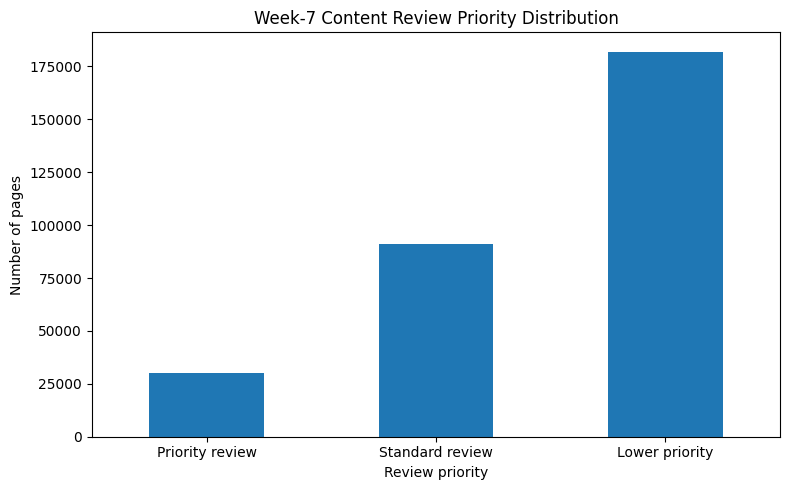

Figure exported to: work/figures/w07_priority_distribution.png

Export verification
-------------------
Queue exists: True
Metrics exists: True
Figure exists: True
Reloaded queue shape: (303321, 10)

All Week-7 exports verified successfully.


In [18]:
# Section 5: export artifacts for the paper

from pathlib import Path
import json

# Create output directories if they do not already exist.
outputs_dir = Path("work/outputs")
figures_dir = Path("work/figures")

outputs_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# 1. Export ranked queue
# ---------------------------------------------------------

queue_path = outputs_dir / "w07_ranked_action_queue.csv"

queue_export.to_csv(
    queue_path,
    index=False
)

print("Queue exported to:", queue_path)
print("Queue rows:", len(queue_export))

# ---------------------------------------------------------
# 2. Export aggregate metrics / receipts
# ---------------------------------------------------------

metrics = {
    "queue_rows": int(len(queue_export)),
    "priority_review_rows": int(
        (queue_export["action_priority"] == "Priority review").sum()
    ),
    "standard_review_rows": int(
        (queue_export["action_priority"] == "Standard review").sum()
    ),
    "lower_priority_rows": int(
        (queue_export["action_priority"] == "Lower priority").sum()
    ),
    "week5_model_roc_auc": 0.8992,
    "week4_baseline_roc_auc": 0.5308,
    "absolute_roc_auc_improvement": 0.3684,
    "features": final_features,
    "purpose": "content refresh decision-support prioritization"
}

metrics_path = outputs_dir / "w07_playbook_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("Metrics exported to:", metrics_path)

# ---------------------------------------------------------
# 3. Create a reusable priority-distribution figure
# ---------------------------------------------------------

import matplotlib.pyplot as plt

priority_order = [
    "Priority review",
    "Standard review",
    "Lower priority"
]

priority_counts = (
    queue_export["action_priority"]
    .value_counts()
    .reindex(priority_order)
)

plt.figure(figsize=(8, 5))
priority_counts.plot(kind="bar")

plt.title("Week-7 Content Review Priority Distribution")
plt.xlabel("Review priority")
plt.ylabel("Number of pages")
plt.xticks(rotation=0)
plt.tight_layout()

figure_path = figures_dir / "w07_priority_distribution.png"

plt.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Figure exported to:", figure_path)

# ---------------------------------------------------------
# 4. Verify exports
# ---------------------------------------------------------

print("\nExport verification")
print("-------------------")

print("Queue exists:", queue_path.exists())
print("Metrics exists:", metrics_path.exists())
print("Figure exists:", figure_path.exists())

assert queue_path.exists()
assert metrics_path.exists()
assert figure_path.exists()

# Verify that the queue can be read back successfully.
queue_check = pd.read_csv(queue_path)

print("Reloaded queue shape:", queue_check.shape)

assert queue_check.shape == queue_export.shape

print("\nAll Week-7 exports verified successfully.")

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.